## SANITY CHECK FOR RT-DETR
The purpose of this notebook is to test the `RT-DETR v2` model with a balanced 300-sample subset of the SixRay dataset (200 train, 100 val) to see if the model learns correctly (it does).

By observing the convergence of the training loss and the initial rise in mAP, we aim to confirm that the model architecture, the dataset loading, and the evaluation metrics are functioning correctly.

**Configuration settings**

In [1]:
from google.colab import drive
drive.mount('/content/drive')


!git clone -b angelo https://github.com/angelo4o4/sixray-kd.git /content/sixray-kd
!bash /content/sixray-kd/scripts/setup_colab.sh

import sys
sys.path.append('/content/sixray-kd')

Mounted at /content/drive
Cloning into '/content/sixray-kd'...
remote: Enumerating objects: 50, done.
remote: Counting objects: 100% (50/50), done.
remote: Compressing objects: 100% (36/36), done.
remote: Total 50 (delta 15), reused 38 (delta 6), pack-reused 0 (from 0)
Receiving objects: 100% (50/50), 1.64 MiB | 20.00 MiB/s, done.
Resolving deltas: 100% (15/15), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.6 MB/s eta 0:00:00
Dataset 'subset_clean.zip' extracted to /content/data


**Imports and device check**

In [2]:
import os
import json
import random
import numpy as np
import torch
from torch.utils.data import Subset
from torch.utils.data import DataLoader
from torch.optim import AdamW
from src.data.dataset import SixRayDataset, collate_fn
from src.models.teacher import load_teacher
from src.engine.evaluator import evaluate_detection

print(f"PyTorch version: {torch.__version__}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

PyTorch version: 2.11.0+cu128
Using device: cuda


In [3]:
# Config
MODEL_NAME     = "PekingU/rtdetr_v2_r50vd"
EPOCHS         = 50
BATCH_SIZE     = 4
LR             = 1e-4
SEED           = 42
NUM_SAMPLES    = 100   # per class for the balanced train subset
VAL_SAMPLES    = 50    # per class for the balanced val subset
CHECKPOINT_DIR = "/content/drive/MyDrive/DatasetAPAI/SIXray_Project/checkpoints"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [5]:
# Paths
LOCAL_EXTRACT_PATH = "/content/data"
TRAIN_IMG_DIR      = os.path.join(LOCAL_EXTRACT_PATH, "train", "images")
TRAIN_JSON         = os.path.join(LOCAL_EXTRACT_PATH, "train.json")
TEST_IMG_DIR       = os.path.join(LOCAL_EXTRACT_PATH, "test", "images")
TEST_JSON          = os.path.join(LOCAL_EXTRACT_PATH, "test.json")

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

**MODEL AND PROCESSOR LOADING**

In [6]:
from src.data.labels import load_label_maps_from_file

id2label, label2id, num_labels = load_label_maps_from_file(TRAIN_JSON)
processor, model = load_teacher(MODEL_NAME, id2label, label2id, device=device)
print(f"Model loaded with {num_labels} classes: {list(id2label.values())}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/444 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/5.28k [00:00<?, ?B/s]

[transformers] You passed `num_labels=5` which is incompatible to the `id2label` map of length `80`.


model.safetensors:   0%|          | 0.00/172M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/770 [00:00<?, ?it/s]

[transformers] RTDetrV2ForObjectDetection LOAD REPORT from: PekingU/rtdetr_v2_r50vd
Key                                                 | Status   |                                                                                        
----------------------------------------------------+----------+----------------------------------------------------------------------------------------
model.decoder.class_embed.{0, 1, 2, 3, 4, 5}.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([80, 256]) vs model:torch.Size([5, 256])
model.enc_score_head.bias                           | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([80]) vs model:torch.Size([5])          
model.decoder.class_embed.{0, 1, 2, 3, 4, 5}.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([80]) vs model:torch.Size([5])          
model.denoising_class_embed.weight                  | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([81, 256]) vs model:torch.Size([6, 256]

Model loaded with 5 classes: ['gun', 'knife', 'wrench', 'pliers', 'scissors']


**SETUP DATALOADER**

In [7]:
def balanced_subset_indices(dataset, num_per_class, seed):
    positive_idx, negative_idx = [], []
    for idx in range(len(dataset)):
        if len(dataset.annotations_per_image[idx]) > 0:
            positive_idx.append(idx)
        else:
            negative_idx.append(idx)

    rng = random.Random(seed)
    train_indices = (
        rng.sample(negative_idx, min(num_per_class, len(negative_idx)))
        + rng.sample(positive_idx, min(num_per_class, len(positive_idx)))
    )
    rng.shuffle(train_indices)
    return train_indices, len(positive_idx), len(negative_idx)


train_dataset = SixRayDataset(TRAIN_IMG_DIR, TRAIN_JSON, processor)
val_dataset = SixRayDataset(TEST_IMG_DIR, TEST_JSON, processor)

train_indices, n_pos, n_neg = balanced_subset_indices(train_dataset, NUM_SAMPLES, SEED)
val_indices, v_pos, v_neg = balanced_subset_indices(val_dataset, VAL_SAMPLES, SEED + 1)

print(f"Full train set: {n_pos} positive / {n_neg} negative images")
print(f"Mini train subset: {len(train_indices)} images")
print(f"Val subset: {len(val_indices)} images")

mini_dataset = Subset(train_dataset, train_indices)
val_subset = Subset(val_dataset, val_indices)

train_loader = DataLoader(
    mini_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
)
val_loader = DataLoader(
    val_subset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
)

batch = next(iter(train_loader))
print(f"Batch image shape: {batch['pixel_values'].shape}")
print(f"First label: {batch['labels'][0]}")

Full train set: 5753 positive / 67049 negative images
Mini train subset: 200 images
Val subset: 100 images
Batch image shape: torch.Size([4, 3, 640, 640])
First label: {'size': tensor([640, 640]), 'image_id': tensor([30217]), 'class_labels': tensor([2, 2, 3, 3, 3, 3, 2]), 'boxes': tensor([[0.3547, 0.3275, 0.4187, 0.1558],
        [0.4197, 0.3321, 0.4837, 0.1952],
        [0.7039, 0.3956, 0.1887, 0.1921],
        [0.5944, 0.4047, 0.1518, 0.1861],
        [0.5011, 0.4455, 0.1605, 0.1800],
        [0.3937, 0.4387, 0.1150, 0.1362],
        [0.3069, 0.4690, 0.1323, 0.1634]]), 'area': tensor([26720.9629, 38668.0391, 14851.8496, 11573.3936, 11836.8535,  6411.7407,
         8855.4609]), 'iscrowd': tensor([0, 0, 0, 0, 0, 0, 0]), 'orig_size': tensor([661, 461])}


In [8]:
# Double checking the percentage of positive and negative images
# TRAINING SET
extracted_pos_train = min(NUM_SAMPLES, n_pos)
extracted_neg_train = min(NUM_SAMPLES, n_neg)
total_extracted_train = extracted_pos_train + extracted_neg_train

perc_pos_train = (extracted_pos_train / total_extracted_train) * 100
perc_neg_train = (extracted_neg_train / total_extracted_train) * 100

print(f"Train Balancing: {perc_pos_train:.1f}% positives ({extracted_pos_train}) | {perc_neg_train:.1f}% negatives ({extracted_neg_train})")

# VALIDATION SET
extracted_pos_val = min(VAL_SAMPLES, v_pos)
extracted_neg_val = min(VAL_SAMPLES, v_neg)
total_extracted_val = extracted_pos_val + extracted_neg_val

perc_pos_val = (extracted_pos_val / total_extracted_val) * 100
perc_neg_val = (extracted_neg_val / total_extracted_val) * 100

print(f"Val Balancing: {perc_pos_val:.1f}% positives ({extracted_pos_val}) | {perc_neg_val:.1f}% negatives ({extracted_neg_val})")

Train Balancing: 50.0% positives (100) | 50.0% negatives (100)
Val Balancing: 50.0% positives (50) | 50.0% negatives (50)


**VISUALIZATION**

Visualization of the first batch

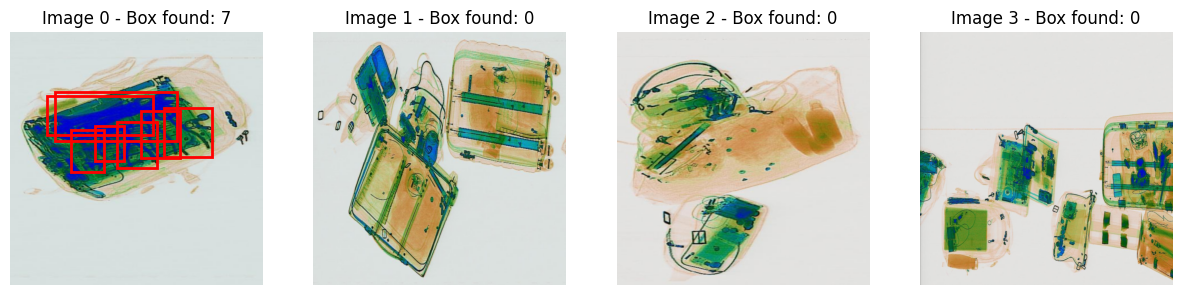

In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def visualize_batch(batch, n_images=4):
    # Taking first elements of the batch
    images = batch["pixel_values"].cpu()
    labels = batch["labels"]

    fig, axs = plt.subplots(1, n_images, figsize=(15, 7))
    if n_images == 1: axs = [axs]

    for i in range(n_images):
        # Processor rescales to [0, 1] (do_normalize=False for RT-DETR)
        img = images[i].permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1)

        axs[i].imshow(img)

        # Drawing bounding boxes
        # RT-DETR uses natively format [cx, cy, w, h] normalized
        h, w, _ = img.shape
        for box in labels[i]["boxes"]:
            cx, cy, bw, bh = box.numpy()
            xmin = (cx - bw/2) * w
            ymin = (cy - bh/2) * h
            rect = patches.Rectangle(
                (xmin, ymin), bw * w, bh * h,
                linewidth=2, edgecolor='r', facecolor='none'
            )
            axs[i].add_patch(rect)

        axs[i].set_title(f"Image {i} - Box found: {len(labels[i]['boxes'])}")
        axs[i].axis('off')

    plt.show()

visualize_batch(batch)

**INSPECTING THE ALL THE BATCHES**

With a dynamic slider to see if the bounding box are matching the objects.

In [10]:
from ipywidgets import interact, IntSlider

# number of images per page
IMAGES_PER_PAGE = 10
TOTAL_PAGES = (len(mini_dataset) - 1) // IMAGES_PER_PAGE

def inspect_dataset(pagina):
    start_idx = pagina * IMAGES_PER_PAGE
    end_idx = min(start_idx + IMAGES_PER_PAGE, len(mini_dataset))

    # 2 x 5 grid
    fig, axs = plt.subplots(2, 5, figsize=(20, 8))
    axs = axs.flatten()

    for i, idx in enumerate(range(start_idx, end_idx)):
        item = mini_dataset[idx]
        img_tensor = item["pixel_values"]
        labels = item["labels"]

        img = img_tensor.permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1)

        axs[i].imshow(img)

        h, w, _ = img.shape
        num_boxes = len(labels["boxes"])

        for box in labels["boxes"]:
            cx, cy, bw, bh = box.numpy()
            xmin = (cx - bw/2) * w
            ymin = (cy - bh/2) * h
            rect = patches.Rectangle(
                (xmin, ymin), bw * w, bh * h,
                linewidth=2, edgecolor='r', facecolor='none'
            )
            axs[i].add_patch(rect)

        # Images and boxes found
        axs[i].set_title(f"Image [{idx}]\nBox: {num_boxes}", fontsize=10)
        axs[i].axis('off')

    for j in range(i + 1, len(axs)):
        axs[j].axis('off')

    plt.tight_layout()
    plt.show()

# Interactive slider
print(f"Dataset total (train): {len(mini_dataset)} images.")
print(f"Available pages: da 0 a {TOTAL_PAGES}")
interact(inspect_dataset, pagina=IntSlider(min=0, max=TOTAL_PAGES, step=1, value=0, description="Page:"));

Dataset total (train): 200 images.
Available pages: da 0 a 19


interactive(children=(IntSlider(value=0, description='Page:', max=19), Output()), _dom_classes=('widget-intera…

**TRAINING & VALIDATION LOOP**

This cell executes the core training process to verify that the model is capable of learning from our dataset. We use the **AdamW** optimizer paired with a **Cosine Annealing scheduler (with warmup)** to stabilize the early stages of training.

Our goal here is to ensure the pipeline works: we want to observe a steady decrease in the training loss and the validation mAP starting to rise above zero. Advanced regularization techniques (like dropout) will be introduced in the final training script.

The total loss is computed automatically by the model during the forward pass. For RT-DETR, this is a weighted sum of three components:
* **L1 Loss:** Absolute error on the bounding box coordinates.
* **GIoU Loss:** Error based on the overlapping area of the bounding boxes.
* **Focal Loss:** Classification error (designed to handle class imbalance).

At the end of each epoch, the model is evaluated on the validation subset, and a checkpoint is saved only if the `mAP` strictly improves.

In [12]:
from transformers import get_cosine_schedule_with_warmup
from tqdm.auto import tqdm

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
# total steps for the LR scheduler
num_training_steps = len(train_loader) * EPOCHS
num_warmup_steps = int(0.1 * num_training_steps)
scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=num_training_steps
)

print(f"Stariting training for {EPOCHS} epochs")
print(f"Total steps: {num_training_steps} | Warmup step: {num_warmup_steps}")

model.train()
best_mAP = 0.0

for epoch in range(EPOCHS):
    epoch_loss = 0
    print(f"\n--- Epoch {epoch + 1}/{EPOCHS} ---")

    pbar = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{EPOCHS} (Training)")

    for step, batch in enumerate(pbar):
        pixel_values = batch["pixel_values"].to(device)
        labels = [{k: v.to(device) for k, v in t.items()} for t in batch["labels"]]

        outputs = model(pixel_values=pixel_values, labels=labels)
        loss = outputs.loss

        loss.backward()
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

        epoch_loss += loss.item()

        # Update tqdm's postfix with current loss and LR
        current_lr = scheduler.get_last_lr()[0]
        pbar.set_postfix(Loss=f"{loss.item():.4f}", LR=f"{current_lr:.6f}")

    avg_loss = epoch_loss / len(train_loader)
    print(f"End of epoch {epoch + 1} - Average Loss: {avg_loss:.4f}")

    val_metrics = evaluate_detection(model, processor, val_loader, device)
    print(
        f"  Val mAP: {val_metrics['map']:.4f} | "
        f"mAP@50: {val_metrics['map_50']:.4f} | "
        f"mAP@75: {val_metrics['map_75']:.4f}"
    )

    # Save only if it's the best mAP so far
    # (Note: Code updated AFTER the first run to avoid saving multiple files on Drive)
    if val_metrics["map"] > best_mAP:
        best_mAP = val_metrics["map"]
        save_path = os.path.join(CHECKPOINT_DIR, "00_rtdetr_best_model.pth")
        torch.save(model.state_dict(), save_path)
        print(f"New best model found at epoch {epoch+1} (mAP: {best_mAP:.4f})! Checkpoint overwritten.")

print("Training finished!")

Stariting training for 50 epochs
Total steps: 2500 | Warmup step: 250

--- Epoch 1/50 ---


Epoch 1/50 (Training):   0%|          | 0/50 [00:00<?, ?it/s]

End of epoch 1 - Average Loss: 761.4008


/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Encountered more than 100 detections in a single image. This means that certain detections with the lowest scores will be ignored, that may have an undesirable impact on performance. Please consider adjusting the `max_detection_threshold` to suit your use case. To disable this warning, set attribute class `warn_on_many_detections=False`, after initializing the metric.
  warnings.warn(*args, **kwargs)


  Val mAP: 0.0001 | mAP@50: 0.0006 | mAP@75: 0.0000
Checkpoint saved: /content/drive/MyDrive/DatasetAPAI/SIXray_Project/checkpoints/00_rtdetr_epoch_1.pth

--- Epoch 2/50 ---


...

End of epoch 48 - Average Loss: 3.5724
  Val mAP: 0.3143 | mAP@50: 0.4159 | mAP@75: 0.3248

--- Epoch 49/50 ---


Epoch 49/50 (Training):   0%|          | 0/50 [00:00<?, ?it/s]

End of epoch 49 - Average Loss: 3.4253
  Val mAP: 0.3141 | mAP@50: 0.4158 | mAP@75: 0.3231

--- Epoch 50/50 ---


Epoch 50/50 (Training):   0%|          | 0/50 [00:00<?, ?it/s]

End of epoch 50 - Average Loss: 3.4753
  Val mAP: 0.3141 | mAP@50: 0.4159 | mAP@75: 0.3231
Training finished!


The model is successfully learning from the data: the Training Loss dropped steadily (down to ~3.47) and the Validation mAP peaked at 36.75% around epoch 29. As expected with only 200 images, we saw some natural overfitting towards the end.